In [1]:
using LinearAlgebra
using BSplineKit
using PyCall
using DelimitedFiles
using Plots
using NonlinearEigenproblems
include("BaseFlow_cavity.jl")
include("Stability_Cavity.jl")

mode = 1:cavity; mode = 2:stationary; mode = 3:rotation;


Main.CRC_STA

In [3]:
Res = 1000
N_cheb = 129
mode = 1
Ro = - 1.0
Co = 2 - Ro - Ro^2
Ts = 0
u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts,mode)
D,D2,z = CRC_BF.Cheb(N_cheb,mode)
F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode)

([-2.3652355178959236e-21; 0.0022065891442621223; … ; -0.0007719927481758689; -3.6829751484828996e-19;;], [1.0; 0.9975417112810869; … ; 0.0006343015333476845; -1.6976977343855913e-19;;], [-1.908815819869238e-21; -1.0359793515841938e-5; … ; -3.6212129157292214e-6; -1.0773200297890632e-20;;])

In [ ]:
R = 275
be = 0.16
OMEGA = 8.0
omega = -0.102
c = 0.01
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
L0_raw,L1_raw,L2_raw= CRC_STA.assemble_mat(cof,D,D2,be,omega,R)     
L0,L1,L2 = CRC_STA.boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 3,maxit = 500 , tol=1e-14)
vel = CRC_STA.eig_full(eigvec,N_cheb,1)
@show eigval

In [ ]:
TITLE = "Flow Field Visualization"
VARIABLES = "X", "Y", "Z", "U" ,"V" 
ZONE T="Step_01", I=1, J=121, K=29, F=POINT

In [213]:
R = 355
be =  0.0
alpha = 0.305
cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
# for alpha = 0.001 : 0.005 : 0.7
# alpha = 0.005
H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
C = eigen(H0,H1)
val = C.values
vec = C.vectors
map_index0 = map(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.02, val)
val_filter0 = val[map_index0]
vec_filter0 = vec[:,map_index0]
indictor = sum(real(val_filter0))/length(val_filter0)
if alpha < 0.031
    addition = 0.004
else
    addition = 0.006
end
map_index = map(x-> (real(x)) > abs(indictor) + addition , val_filter0)
val_filter1 = val_filter0[map_index]
vec_filter1 = vec_filter0[:,map_index]
val_filter2 = val_filter1[findmax(imag.(val_filter1))[2]]
vec_filter2 = vec_filter1[:,findmax(imag.(val_filter1))[2]];
if 0.2 < alpha < 0.4
    # map_index1 = map(x-> abs(imag(x)) < (alpha * 100 ) * abs(imag(val_filter2)), val_filter1)
    idx = partialsortperm(real(val_filter1), 1:3, by = x -> abs(x - real(val_filter2)))
    val_filter = val_filter1[idx]
    vec_filter = vec_filter1[:,idx]
else
    val_filter = val_filter2
    vec_filter = vec_filter2
end
val_target = val_filter
vec_target = vec_filter
println("$(alpha)")
val_target

0.305


3-element Vector{ComplexF64}:
 0.036317803923590554 - 1.0716081415609039e-5im
  0.04407542917292518 - 0.003062493215876513im
 0.012965874236341901 - 0.0046162153367362005im

In [ ]:
 0.006784436877105752 - 0.004658874946355313im
 0.011465074109312271 - 0.004400232241136477im
  0.03443888181824502 - 0.002702047253184661im
  0.03651669764930047 - 0.000522899165933439im

In [201]:
val = val_target[4] 
vec = vec_target[:,4]
writedlm("test.dat",[])
for be = 0.0 : -0.01 : -0.3 
    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
    val,vec = rayleigh_quotient_iteration(H0, H1, val+ 0.01im, vec)
    open("test.dat","a") do io
        writedlm(io,[be val])
    end
end

In [161]:
indictor

-0.000487242677133279

In [92]:
val_filter2
# imag.(val_target[1])

0.0432178369575622 + 0.0006099219598703281im

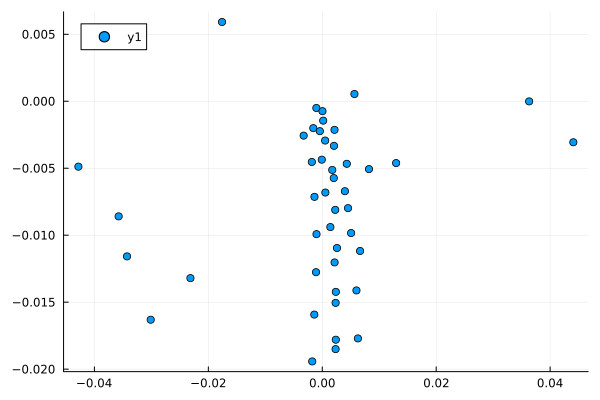

In [209]:
scatter(real(val_filter0),imag(val_filter0))

In [11]:
function EigenCore(cof,D,D2,be,alpha,R,N_cheb)
    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
    C = eigen(H0,H1)
    val = C.values
    vec = C.vectors
    map_index0 = map(x-> abs(real(x)) < 0.3 && abs(imag(x)) < 0.5, val)
    val_filter0 = val[map_index0]
    vec_filter0 = vec[:,map_index0]
    indictor = sum(real(val_filter0))/length(val_filter0)
    if alpha < 0.031
        addition = 0.003
    else
        addition = 0.007
    end
    val_filter1 = val_filter0[map_index]
    vec_filter1 = vec_filter0[:,map_index]
    val_filter2 = val_filter1[findmax(imag.(val_filter1))[2]]
    vec_filter2 = vec_filter1[:,findmax(imag.(val_filter1))[2]];
    if imag(val_filter2) > 0
        val_target = val_filter2
        vec_target = vec_filter2
    else
        map_index1 = map(x-> abs(imag(x)) < 1.5 * abs(imag(val_filter2)), val_filter1)
        val_filter = val_filter1[map_index1]
        vec_filter = vec_filter1[:,map_index1]
        val_target = val_filter[findmax(real.(val_filter))[2]]
        vec_target = vec_filter[:,findmax(real.(val_filter))[2]];
    end
        return val_target,vec_target
end

EigenCore (generic function with 1 method)

In [14]:
function interation(R_ini, R_end, alpha_ini, alpha_end, be_up, be_down, N_cheb)
    u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(1000,-1,0.0,1)
    D,D2,z = CRC_BF.Cheb(N_cheb,1)
    F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,1)
    be_pos_range = 0.005 : 0.005 : be_up
    be_neg_range = -0.005 : -0.005 : be_down
    N_total_steps = 1 + length(be_pos_range) + length(be_neg_range)

    idx_root = length(be_neg_range) + 1

    alpha_range = collect(alpha_ini : 0.01 : alpha_end)

    for R = R_ini : -5 : R_end
        println("正在计算雷诺数 = $R ...")
        cof = CRC_STA.Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2, 1000)
        tasks = Vector{Task}(undef, length(alpha_range))

        for i in 1 : length(alpha_range)
            alpha = alpha_range[i]

            tasks[i] = Threads.@spawn begin
                
                local_mat = zeros(Float64, N_total_steps, 5)
                
                val_root,vec_root = EigenCore(cof,D,D2,0.0,alpha,R,N_cheb)
                local_mat[idx_root, :] .= (R, alpha, 0.0, real(val_root), imag(val_root))
                
                val, vec = val_root, vec_root
                for (i, be) in enumerate(be_pos_range)
                    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
                    val,vec = rayleigh_quotient_iteration(H0,H1,val, vec)

                    curr_idx = idx_root + i
                    local_mat[curr_idx, :] .= (R, alpha, be, real(val), imag(val))
    
                    if local_mat[curr_idx, 5] < 0 && local_mat[curr_idx - 1, 5] > 0
                        if curr_idx < N_total_steps
                            for remain_idx in (curr_idx + 1) : N_total_steps
                                local_mat[remain_idx, :] .= (R, alpha, be_pos_range[remain_idx - idx_root], -1.0, -1.0)
                            end
                        end
                        break 
                    end
                        
                end
                
                val, vec = val_root, vec_root
                for (i, be) in enumerate(be_neg_range)
                    H0,H1 = CRC_STA.assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
                    val,vec = rayleigh_quotient_iteration(H0,H1,val, vec)
                    curr_idx = idx_root - i
                    local_mat[curr_idx, :] .= (R, alpha, be, real(val), imag(val))

                    if local_mat[curr_idx, 5] < 0 && local_mat[curr_idx + 1, 5] > 0
                        if curr_idx > 1
                            for remain_idx in 1 : (curr_idx - 1)
                                local_mat[remain_idx, :] .= (R, alpha, be_neg_range[idx_root - remain_idx], -1.0, -1.0)
                            end
                        end
                        break 
                    end
                end

                return local_mat
            end
        end
        results_mat = [fetch(t) for t in tasks]
        full_R_data = vcat(results_mat...)
        full_R_data = sortslices(full_R_data, dims=1, by=x->(x[2], x[3]))
        filename = "test.dat"
        open(filename, "w") do io
            println(io, "TITLE = \"Stability Analysis\"")
            println(io, "VARIABLES = \"R\", \"alpha\", \"beta\", \"omega_r\", \"omega_i\"")
            println(io, "ZONE T=\"R=$R\", I=$N_total_steps, J=$(length(alpha_range)), F=POINT")
            writedlm(io, full_R_data)
        end
    end
end

interation (generic function with 1 method)

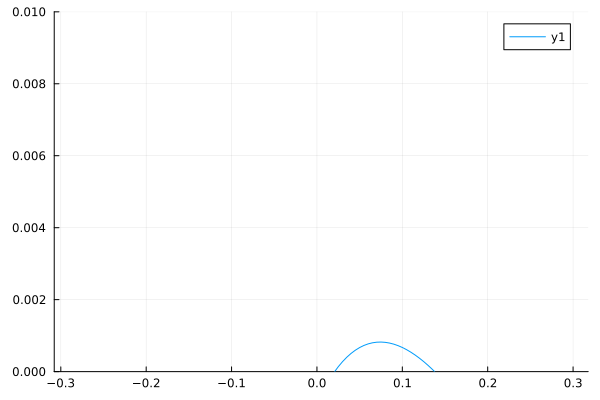

In [19]:
data = readdlm("test.dat",skipstart=3)
plot(data[3:end,3],data[3:end,5],ylims=[0,0.01])

In [260]:
open("Stability_Zarf.dat", "w") do io
    for R = 85 : 5 : 500
        data = readdlm("R=$R.dat",skipstart=3)
        writedlm(io, data)
    end
end

In [18]:
R_ini= 350
R_end = 350
be_up = 0.3
be_down = -0.3
alpha_ini = 0.281
alpha_end = 0.281
N_cheb = 129
interation(R_ini, R_end, alpha_ini, alpha_end, be_up, be_down, N_cheb)

正在计算雷诺数 = 350 ...


In [97]:
function rayleigh_quotient_iteration(A, B, sigma, q0=rand(ComplexF64, size(A, 1)))
    tol = 1e-8
    sigma_current = ComplexF64(sigma[1]) 
    q = q0 / norm(q0) # 必须使用欧几里得范数
    
    for i in 1:20
        sigma_old = sigma_current
        
        v = (A - sigma_current * B) \ (B * q)
        q = v / norm(v)
        
        num = dot(q, A * q)
        den = dot(q, B * q)
        sigma_current = num / den
        
        if abs(sigma_current - sigma_old) < tol
            return sigma_current, q
        end
    end
    @warn "RQI failed to converge"
    return sigma_current, q
end

rayleigh_quotient_iteration (generic function with 2 methods)